# Tutorial 02 — Nuvens de pontos em S² e S³

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 2)
torch.manual_seed(SEED + 2)
OUT = ROOT / "estudos" / "tutorial_02" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 2, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260910 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## Exercício 1

> **Exercise 1 — a second, independent test.**
> The $z$-histogram checks the marginal in one direction only; a scheme could pass
> it and still be non-uniform in $\theta$.
>
> (a) Choose a fixed unit vector $u$ and histogram $\langle X_i, u \rangle$. What
> must the answer be, and why does taking a *random* $u$ make the test stronger?
>
> (b) Estimate the area of the spherical cap $\{z > 0.8\}$ by the fraction of
> sample points inside it, for each of the three schemes. Compare with the exact
> value $\tfrac{1-0.8}{2} = 0.1$ and report the Monte-Carlo error $\sim 1/\sqrt N$.
>
> (c) The naive scheme is *correct* for $S^1$ with uniform $\theta$. Why? At which
> step of §1.1 does the argument for $S^2$ break down, and what happens on $S^{n-1}$
> for $n \geq 4$?

### Resolução

**(a)** Para $X$ uniforme em $S^2$ e qualquer vetor unitário $u$, $X\cdot u\sim U[-1,1]$, porque uma rotação leva $u$ ao eixo vertical e preserva a medida. Uma direção aleatória reduz o risco de testar apenas um eixo que esconda o viés; nenhuma coleção finita de histogramas prova uniformidade. A igualdade de todas as projeções unidimensionais caracterizaria a distribuição.

**(b)** A fração exata da área é $p=0{,}1$; a área é $4\pi p=0{,}4\pi$. Para amostragem i.i.d. correta, o erro-padrão da fração é $\sqrt{p(1-p)/N}$, não simplesmente $1/\sqrt N$ sem constante. Para o método ingênuo, o erro amostral diminui, mas o viés permanece: $P(z>0{,}8)=\arccos(0{,}8)/\pi\approx0{,}2048$.

**(c)** Em $S^1$, o elemento de comprimento é $d\theta$, logo o ângulo uniforme é correto. Em $S^2$, a área é $\sin\varphi\,d\varphi\,d\theta$: o fator jacobiano não é constante. Em dimensões superiores aparecem potências sucessivas de senos; sortear todos os ângulos uniformemente continua incorreto.

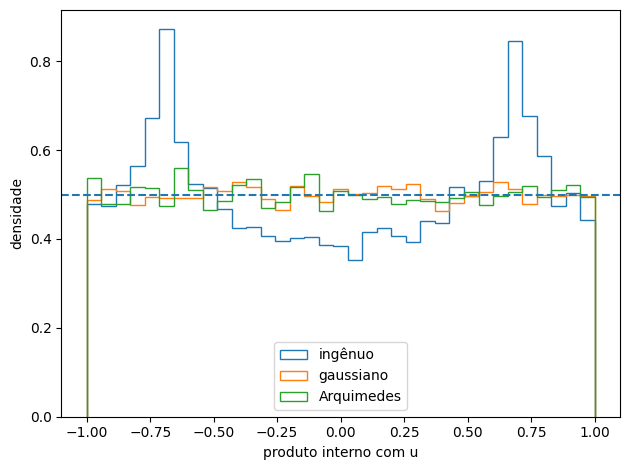

    metodo  fracao     area  erro_absoluto  erro_padrao  KS_projecao
   ingênuo 0.20620 2.591186        0.10620     0.002861     0.042369
 gaussiano 0.09715 1.220823        0.00285     0.002094     0.003331
Arquimedes 0.09965 1.252239        0.00035     0.002118     0.005570
Erro-padrão teórico correto: 0.0021213203435596424


In [2]:
from scipy.stats import kstest
N=20000
phi=rng.uniform(0,np.pi,N);theta=rng.uniform(0,2*np.pi,N)
naive=np.column_stack((np.sin(phi)*np.cos(theta),np.sin(phi)*np.sin(theta),np.cos(phi)))
z=rng.uniform(-1,1,N);th=rng.uniform(0,2*np.pi,N)
arch=np.column_stack((np.sqrt(1-z*z)*np.cos(th),np.sqrt(1-z*z)*np.sin(th),z))
samples={'ingênuo':naive,'gaussiano':sphere(N,3,rng),'Arquimedes':arch}
u=sphere(1,3,rng)[0];rows=[]
plt.figure()
for name,X in samples.items():
    proj=X@u;p=float((X[:,2]>.8).mean())
    rows.append(dict(metodo=name,fracao=p,area=4*np.pi*p,erro_absoluto=abs(p-.1),
                     erro_padrao=np.sqrt(p*(1-p)/N),KS_projecao=kstest((proj+1)/2,'uniform').statistic))
    plt.hist(proj,bins=35,density=True,histtype='step',label=name)
plt.axhline(.5,linestyle='--');plt.xlabel('produto interno com u');plt.ylabel('densidade');plt.legend()
figure('ex01_projecoes',OUT)
cap_df=table(rows,'ex01_calota',OUT)
print('Erro-padrão teórico correto:',np.sqrt(.1*.9/N))

## Exercício 2

> **Exercise 2 — $S^1$, and the failure of the obvious generalisation.**
> Write `sample_circle_naive(n, rng)` using uniform $\theta$, and verify it is
> uniform. Then attempt the direct analogue of Archimedes on $S^3$: draw the last
> coordinate uniformly on $[-1,1]$ and the remaining three uniformly on a sphere of
> the matching radius. Test the result against `sample_sphere(n, 4, rng)` using the
> statistic from Exercise 1(a). What is the true density of a single coordinate of a
> uniform point on $S^{n-1}$? (You will derive it in §6 — attempt it first.)

### Resolução

No círculo, a parametrização $(\cos\theta,\sin\theta)$ tem velocidade unitária e induz comprimento uniforme. Na esfera $S^{n-1}$, o elemento de área em fatias $z=t$ fornece

$$f_n(t)=\frac{\Gamma(n/2)}{\sqrt\pi\,\Gamma((n-1)/2)}(1-t^2)^{(n-3)/2},\quad -1<t<1.$$

Equivalentemente, $(t+1)/2\sim\mathrm{Beta}((n-1)/2,(n-1)/2)$. O raio da fatia contribui com $(1-t^2)^{(n-2)/2}$ e a inclinação acrescenta $(1-t^2)^{-1/2}$. Para $n=4$, a densidade é $2\sqrt{1-t^2}/\pi$, não uniforme. A generalização correta sorteia essa marginal e, condicionalmente a $t$, uma direção uniforme em $S^{n-2}$.

Círculo: média de exp(i*k*theta), k=1,...,4: [np.float64(0.003155459190967669), np.float64(0.004554250747320257), np.float64(0.0037016618335186983), np.float64(0.0026441810910439907)]
z uniforme: incorreto E[z²]= 0.33177324498001837 KS correto= 0.05805885864797057
Gaussiana normalizada E[z²]= 0.24855059768738502 KS correto= 0.008184850400060006


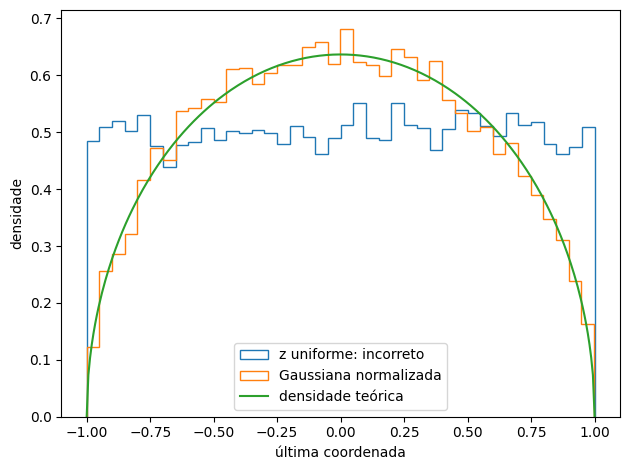

In [3]:
from scipy.special import gamma
from scipy.stats import beta
def sample_circle_naive(n,rng):
    t=rng.uniform(0,2*np.pi,n);return np.column_stack((np.cos(t),np.sin(t)))
C=sample_circle_naive(15000,rng)
print('Círculo: média de exp(i*k*theta), k=1,...,4:',
      [abs(np.mean((C[:,0]+1j*C[:,1])**k)) for k in range(1,5)])
t=rng.uniform(-1,1,20000)
bad4=np.column_stack((sphere(len(t),3,rng)*np.sqrt(1-t*t)[:,None],t))
good4=sphere(len(t),4,rng)
plt.figure()
for name,X in [('z uniforme: incorreto',bad4),('Gaussiana normalizada',good4)]:
    plt.hist(X[:,-1],bins=40,density=True,histtype='step',label=name)
    print(name,'E[z²]=',np.mean(X[:,-1]**2),'KS correto=',kstest((X[:,-1]+1)/2,beta(1.5,1.5).cdf).statistic)
grid=np.linspace(-1,1,300);plt.plot(grid,2/np.pi*np.sqrt(1-grid*grid),label='densidade teórica')
plt.xlabel('última coordenada');plt.ylabel('densidade');plt.legend();figure('ex02_s3_marginal',OUT)

## Exercício 3

> **Exercise 3 — discretisation quality.**
> (a) The Euler characteristic printed above should be $2$. Confirm it, and explain
> why it is a genuine test of the triangulation rather than a tautology.
>
> (b) Use the triangulation to estimate the surface area of $S^2$ by summing
> triangle areas. Plot the relative error against $N$ on log-log axes for
> $N = 50, 100, \dots, 5000$, for both the Fibonacci and the random cloud. What
> convergence rates do you observe, and which one would you want for a quadrature
> rule?
>
> (c) *(harder)* The Fibonacci lattice is not exactly uniform near the poles. Detect
> this by plotting the triangle-area distribution as a function of $|z|$.

### Resolução

**(a)** Construo a lista de arestas distintas a partir dos triângulos, em vez de impor $E=3F/2$, e verifico que cada aresta pertence a duas faces. Assim, $V-E+F=2$ é uma checagem combinatória útil contra índices/arestas incorretos. Ainda não é uma prova independente de toda a topologia: a garantia de convexidade já explica o resultado esperado.

**(b)** Cada triângulo contribui com $\frac12\|(b-a)\times(c-a)\|$. A área do poliedro inscrito fica abaixo de $4\pi$. Para malhas quase uniformes, a escala linear é $h\sim N^{-1/2}$ e o erro global de área é tipicamente $O(h^2)=O(N^{-1})$; isso é uma previsão assintótica, não a imposição da inclinação do gráfico. Repetições aleatórias e a rede determinística são comparadas abaixo. Fibonacci tende a ter células mais regulares, útil para quadratura, mas convergência da área não garante a mesma taxa para qualquer integrando.

**(c)** A rede é quase uniforme, não uma tesselação exatamente equiárea. As áreas normalizadas por sua média são examinadas em faixas de $|z|$ e diretamente nos triângulos; diferenças polares pequenas não contradizem convergência da medida empírica.

V,E,F,chi: 300 894 596 2


   N    metodo  erro_medio   desvio
  50 Fibonacci    0.061861 0.000000
  50 aleatório    0.105464 0.003256
 100 Fibonacci    0.031139 0.000000
 100 aleatório    0.054307 0.002225
 150 Fibonacci    0.020710 0.000000
 150 aleatório    0.039904 0.001051
 200 Fibonacci    0.015611 0.000000
 200 aleatório    0.030186 0.001607
 250 Fibonacci    0.012480 0.000000
 250 aleatório    0.023676 0.001074
 300 Fibonacci    0.010370 0.000000
 300 aleatório    0.018904 0.000594
 350 Fibonacci    0.008877 0.000000
 350 aleatório    0.017120 0.000290
 400 Fibonacci    0.007773 0.000000
 ...       ...         ...      ...
4650 aleatório    0.001300 0.000019
4700 Fibonacci    0.000663 0.000000
4700 aleatório    0.001280 0.000016
4750 Fibonacci    0.000656 0.000000
4750 aleatório    0.001257 0.000009
4800 Fibonacci    0.000649 0.000000
4800 aleatório    0.001246 0.000013
4850 Fibonacci    0.000642 0.000000
4850 aleatório    0.001237 0.000024
4900 Fibonacci    0.000636 0.000000
4900 aleatório    0.001223 0

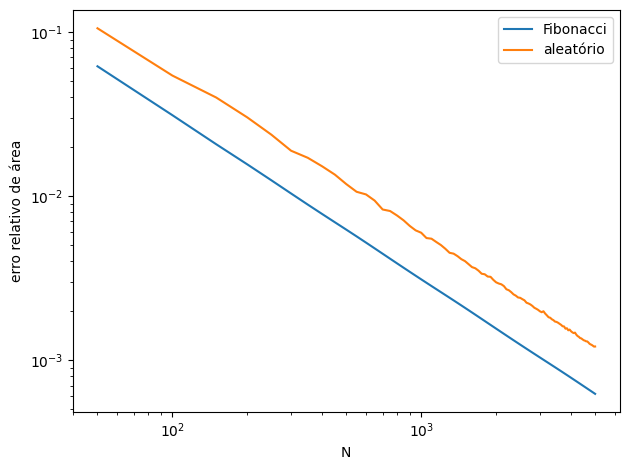

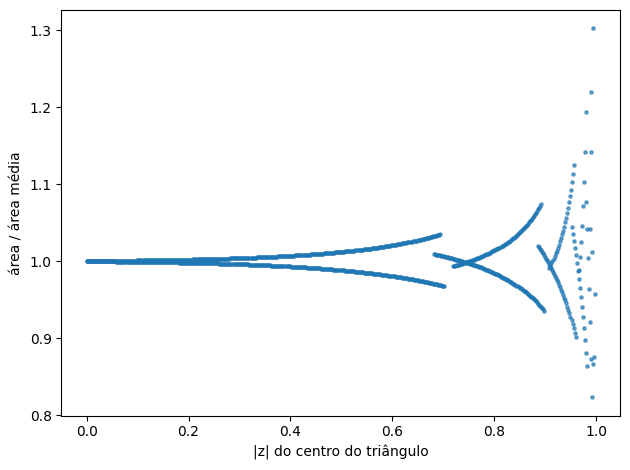

In [4]:
from collections import Counter
X=fibonacci(300);tri=ConvexHull(X).simplices
edges=Counter(tuple(sorted(e)) for t in tri for e in [(t[0],t[1]),(t[1],t[2]),(t[2],t[0])])
chi=len(X)-len(edges)+len(tri)
assert chi==2 and set(edges.values())=={2}
print('V,E,F,chi:',len(X),len(edges),len(tri),chi)
rows=[]
for n in range(50,5001,50):
    for name in ['Fibonacci','aleatório']:
        errors=[]
        for _ in range(1 if name=='Fibonacci' else 3):
            X=fibonacci(n) if name=='Fibonacci' else sphere(n,3,rng)
            h=ConvexHull(X);errors.append((4*np.pi-h.area)/(4*np.pi))
        rows.append(dict(N=n,metodo=name,erro_medio=np.mean(errors),desvio=np.std(errors)))
area_df=table(rows,'ex03_convergencia_area',OUT)
plt.figure()
for name,g in area_df.groupby('metodo'):
    plt.loglog(g.N,g.erro_medio,label=name)
    tail=g[g.N>=1000];print(name,'inclinação:',np.polyfit(np.log(tail.N),np.log(tail.erro_medio),1)[0])
plt.xlabel('N');plt.ylabel('erro relativo de área');plt.legend();figure('ex03_taxa_area',OUT)
X=fibonacci(1000);tri=ConvexHull(X).simplices;T=X[tri]
areas=.5*np.linalg.norm(np.cross(T[:,1]-T[:,0],T[:,2]-T[:,0]),axis=1)
zabs=np.abs(T.mean(axis=1)[:,2])
plt.figure();plt.scatter(zabs,areas/areas.mean(),s=5,alpha=.4)
plt.xlabel('|z| do centro do triângulo');plt.ylabel('área / área média');figure('ex03_polos',OUT)

## Exercício 4

> **Exercise 4 — the metric matters.**
> (a) Repeat the distance-distribution plot for $S^{n-1}$ with $n = 2, 3, 10$. For
> $S^1$ the geodesic distance is uniform on $[0,\pi]$; for $S^2$ it is
> $\frac12 \sin d$. Guess and then verify the general density
> $\rho_n(d) \propto \sin^{n-2} d$. Where does the exponent come from geometrically?
>
> (b) Build the $k$-nearest-neighbour graph of a cloud on $S^2$ under each metric
> and confirm they coincide. Construct a manifold and a sampling for which the
> nearest-neighbour graphs would *not* coincide — what property of the sphere are
> you using?
>
> (c) Compute the *graph* distance in the $k$-NN graph (shortest path, with edges
> weighted by chordal length) and plot it against the true geodesic distance. For
> which $k$ is the approximation good? This is the core idea of Isomap, and a
> preview of Tutorial 8.

### Resolução

**(a)** Fixar um ponto e usar coordenadas geodésicas polares dá $dA=\sin^{n-2}(d)\,dd\,dA_{S^{n-2}}$. Portanto
$$\rho_n(d)=\frac{\Gamma(n/2)}{\sqrt\pi\Gamma((n-1)/2)}\sin^{n-2}d.$$
A potência é a dimensão da esfera transversal, $n-2$.

**(b)** Na esfera unitária, $d_c=2\sin(d_g/2)$ é estritamente crescente para $d_g\in[0,\pi]$. Assim, as ordenações de vizinhos coincidem, salvo empates. Isso é especial: numa hélice quase fechada, as extremidades são próximas no ambiente e distantes ao longo da curva. O código fornece um contraexemplo explícito.

**(c)** Pesos cordais aproximam arcos apenas em arestas curtas. Um $k$ pequeno pode desconectar o grafo; grande demais introduz atalhos. Relato conectividade, erro relativo médio e gráfico contra a geodésica, em vez de dar um $k$ universal.

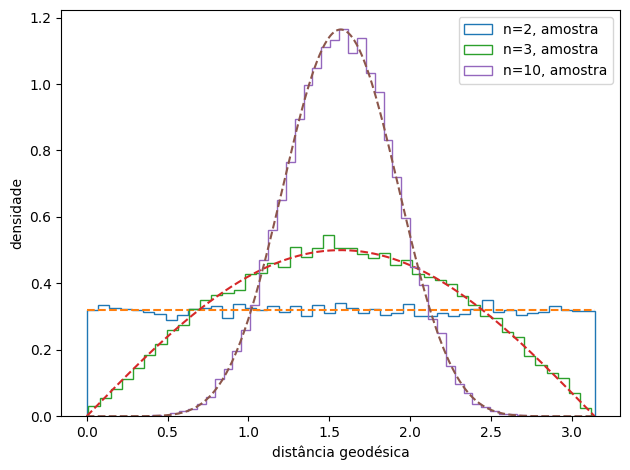

Hélice: vizinho do ponto 0 no ambiente / intrínseco: 2 1


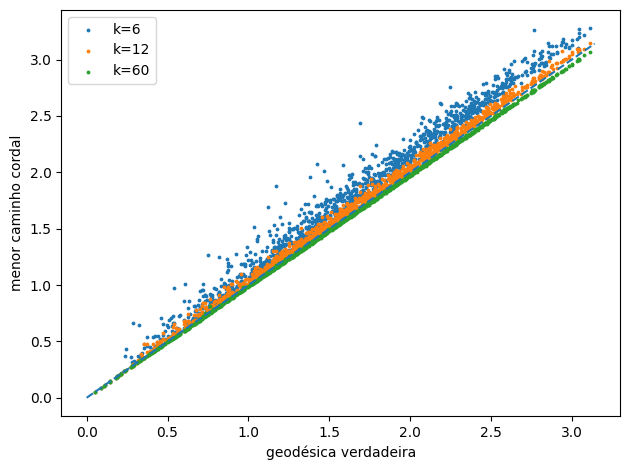

 k  componentes  erro_relativo_medio
 3            3             0.579308
 6            1             0.104760
12            1             0.028862
24            1             0.006188
60            1             0.011806


,k,componentes,erro_relativo_medio
0,3,3,0.579308
1,6,1,0.104760
2,12,1,0.028862
3,24,1,0.006188
4,60,1,0.011806


In [5]:
from scipy.sparse.csgraph import shortest_path,connected_components
plt.figure();grid=np.linspace(0,np.pi,400)
for dim in [2,3,10]:
    X=sphere(25000,dim,rng);Y=sphere(25000,dim,rng)
    ds=np.arccos(np.clip(np.sum(X*Y,axis=1),-1,1))
    plt.hist(ds,bins=45,density=True,histtype='step',label=f'n={dim}, amostra')
    c=gamma(dim/2)/(np.sqrt(np.pi)*gamma((dim-1)/2))
    plt.plot(grid,c*np.sin(grid)**(dim-2),linestyle='--')
plt.xlabel('distância geodésica');plt.ylabel('densidade');plt.legend();figure('ex04_distribuicao',OUT)
X=sphere(550,3,rng);Dg=geodesic(X);Dc=distance.squareform(distance.pdist(X))
assert np.array_equal(np.argsort(Dg,axis=1)[:,1:13],np.argsort(Dc,axis=1)[:,1:13])
t=np.array([0.,.2,2*np.pi]);H=np.column_stack((np.cos(t),np.sin(t),.01*t))
DH=distance.squareform(distance.pdist(H)); intrinsic=np.sqrt(1.0001)*np.abs(t[:,None]-t[None])
print('Hélice: vizinho do ponto 0 no ambiente / intrínseco:',np.argsort(DH[0])[1],np.argsort(intrinsic[0])[1])
assert np.argsort(DH[0])[1]!=np.argsort(intrinsic[0])[1]
rows=[];plt.figure()
for k in [3,6,12,24,60]:
    W=knn_adjacency(X,k);weighted=W.multiply(Dc);Dpath=shortest_path(weighted,directed=False)
    good=np.isfinite(Dpath)&(Dg>1e-7)
    rows.append(dict(k=k,componentes=connected_components(W,directed=False)[0],
                     erro_relativo_medio=np.mean(abs(Dpath[good]-Dg[good])/Dg[good])))
    if k in [6,12,60]:
        ids=np.flatnonzero(good)[::250];plt.scatter(Dg.ravel()[ids],Dpath.ravel()[ids],s=3,label=f'k={k}')
plt.plot([0,np.pi],[0,np.pi],linestyle='--');plt.xlabel('geodésica verdadeira');plt.ylabel('menor caminho cordal')
plt.legend();figure('ex04_isomap',OUT);table(rows,'ex04_grafos',OUT)

## Exercício 5

> **Exercise 5 — split by orbit, not by sample.** *(the most important exercise here)*
>
> Build a dataset with a deliberate symmetry: take $M = 200$ "base" point clouds of
> $50$ points each, sampled from a spherical cap of random centre and radius, and
> give each a label $y$ = the cap's angular radius. Then *augment*: replace each
> cloud by $8$ randomly rotated copies, all carrying the same label. You now have
> $1600$ samples in $200$ orbits.
>
> (a) Extract a rotation-**invariant** feature vector (e.g. the sorted pairwise
> geodesic-distance quantiles) and fit a linear model with a random $80/20$ split.
> Record the test error.
>
> (b) Repeat with a *non*-invariant feature vector (e.g. the raw coordinates of the
> cloud's centroid). Record the test error.
>
> (c) Now redo (b) splitting by **orbit** — all $8$ copies of a base cloud go to the
> same side of the split. Compare the three test errors.
>
> You should find that (b) looks excellent and is a lie: the model has seen a rotated
> copy of every test cloud during training. This is not a contrived failure mode; it
> is one of the commonest ways published computational results turn out to be wrong.

### Resolução

**(a–c)** Os três ajustes pedidos são feitos exatamente com 200 nuvens-base, 50 pontos por nuvem e oito rotações, com partição 80/20 por amostra ou por órbita. Acrescento o modelo invariante com partição por órbita, para uma comparação controlada: mudar simultaneamente representação e divisão confunde os dois efeitos.

**Correção da previsão do enunciado.** Um modelo linear nas três coordenadas do centróide não tem capacidade geral para memorizar 200 órbitas nem para recuperar o raio independentemente da rotação. Se as rotações são Haar-uniformes, $E[\bar X\mid r]=0$ e a covariância populacional entre cada coordenada e o raio é zero. O ótimo linear populacional é, portanto, constante. Não é matematicamente obrigatório que o caso (b) seja excelente.

O vazamento existe na divisão por amostra: quase todas as órbitas de teste aparecem no treino. Para mostrar seu efeito isoladamente, faço ainda um controle 1-NN com características invariantes e **rótulos aleatórios por órbita**. Memorizar a identidade da órbita dá erro próximo de zero no split errado e falha em órbitas inéditas. Esse controle não substitui os três ajustes solicitados; explica quando a armadilha se torna observável.

In [6]:
from scipy.spatial.transform import Rotation
from sklearn.model_selection import train_test_split,GroupShuffleSplit
from sklearn.neighbors import KNeighborsRegressor
M=200;clouds=[];labels=[];groups=[];inv=[];raw=[]
for j in range(M):
    radius=rng.uniform(.15,1.25);z=rng.uniform(np.cos(radius),1,50);t=rng.uniform(0,2*np.pi,50)
    C=np.column_stack((np.sqrt(1-z*z)*np.cos(t),np.sqrt(1-z*z)*np.sin(t),z))
    C=C@Rotation.random(random_state=rng).as_matrix().T
    for a in range(8):
        X=C@Rotation.random(random_state=rng).as_matrix().T
        ds=geodesic(X)[np.triu_indices(50,1)]
        inv.append(np.quantile(ds,np.linspace(.05,.95,19)))
        raw.append(X.mean(0));labels.append(radius);groups.append(j)
F=np.array(inv);C=np.array(raw);y=np.array(labels);groups=np.array(groups)
tr,te=train_test_split(np.arange(len(y)),test_size=.2,random_state=0)
gtr,gte=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=0).split(C,y,groups))
rows=[]
for name,features,a,z in [('a: invariante/amostra',F,tr,te),('b: centróide/amostra',C,tr,te),
                         ('c: centróide/órbita',C,gtr,gte),('controle: invariante/órbita',F,gtr,gte)]:
    model=make_pipeline(StandardScaler(),LinearRegression()).fit(features[a],y[a])
    rows.append(dict(caso=name,MSE=mean_squared_error(y[z],model.predict(features[z])),
                     baseline=mean_squared_error(y[z],np.full(len(z),y[a].mean())),
                     orbitas_compartilhadas=len(set(groups[a])&set(groups[z]))))
leak_df=table(rows,'ex05_splits',OUT)
random_y=rng.normal(size=M)[groups];rows=[]
for name,a,z in [('amostra',tr,te),('órbita',gtr,gte)]:
    model=KNeighborsRegressor(n_neighbors=1).fit(F[a],random_y[a])
    rows.append(dict(split=name,MSE_rotulo_aleatorio=mean_squared_error(random_y[z],model.predict(F[z]))))
table(rows,'ex05_controle_memorizacao',OUT)
assert not set(groups[gtr])&set(groups[gte])

                       caso      MSE  baseline  orbitas_compartilhadas
      a: invariante/amostra 0.000694  0.097841                     168
       b: centróide/amostra 0.097726  0.097841                     168
        c: centróide/órbita 0.094760  0.094932                       0
controle: invariante/órbita 0.001076  0.094932                       0
  split  MSE_rotulo_aleatorio
amostra               0.00000
 órbita               1.83007


## Exercício 6

> **Exercise 6 — $S^3$ hands-on.**
> (a) The unit quaternions form a group. Implement quaternion multiplication and
> check numerically that `quat_to_rotation` is a homomorphism onto $SO(3)$:
> $R(q_1 q_2) = R(q_1) R(q_2)$. Confirm the kernel is $\{\pm 1\}$.
>
> (b) Verify the Hopf fibre through $q$ is exactly the orbit of $q$ under
> right-multiplication by the unit complex numbers, and that distinct fibres are
> disjoint (sample two nearby base points and compute the minimum distance between
> their fibres).
>
> (c) Two distinct fibres are *linked*. Compute their linking number numerically
> from the Gauss integral, or argue it from the picture. What does this say about
> $\pi_3(S^2)$?
>
> (d) *(challenge)* $\mathbb{RP}^3 \cong SO(3)$ is $S^3$ with antipodes identified.
> Sample $SO(3)$ uniformly, map each rotation to the *closer* of its two
> quaternion lifts, and visualise the result in the Mollweide diagram above. What
> changes?

### Resolução

**(a)** Para $q=(w,v)$ e $p=(s,u)$, o produto de Hamilton é $(ws-v\cdot u,\;wu+sv+v\times u)$. A ação $x\mapsto qxq^{-1}$ em quaternions imaginários preserva norma e orientação; composição corresponde à multiplicação. Seu núcleo são os quaternions unitários que comutam com todos os imaginários: os reais $\pm1$. Toda rotação de ângulo $\theta$ e eixo $u$ possui levantamentos $\pm(\cos(\theta/2),u\sin(\theta/2))$, provando sobrejetividade.

**(b)** É necessário fixar convenções. A fórmula complexa do notebook é $h(z_1,z_2)=(2\Re(z_1\bar z_2),2\Im(z_1\bar z_2),|z_1|^2-|z_2|^2)$, com órbita $(e^{it}z_1,e^{it}z_2)$. Para interpretar essa órbita como multiplicação **à direita**, use $q=z_1+jz_2$: os componentes de Hamilton são $(a,b,c,-d)$, e não $(a,b,c,d)$. O teste abaixo faz essa conversão explicitamente. Pontos com imagens distintas não podem estar na mesma fibra; uma distância mínima amostrada positiva ilustra, mas não prova, a disjunção.

**(c)** A integral de Gauss calcula o número de enlace das fibras projetadas estereograficamente. Seu módulo tende a 1; o sinal depende da orientação. Analiticamente, a sequência exata da fibração $S^1\to S^3\to S^2$ e $\pi_3(S^1)=\pi_2(S^1)=0$ dão $\pi_3(S^2)\cong\pi_3(S^3)=\mathbb Z$. O mapa de Hopf representa um gerador. A figura isoladamente não demonstra esse grupo.

**(d)** “O mais próximo” precisa de uma referência: escolho o levantamento mais próximo de $+1$, isto é, $w\geq0$. A fronteira $w=0$ tem medida zero e ainda identifica antipodas. A base de Hopf não muda quando $q\mapsto-q$; a fase muda por $\pi$. O diagrama não transforma $S^3$ num produto global $S^2\times S^1$: uma fase global contínua não existe.

Erro do homomorfismo: 2.220446049250313e-16
Distância mínima amostrada entre fibras: 0.17269790421073394
 pontos_por_fibra   enlace
              150 1.000457
              300 1.000114
              600 1.000029


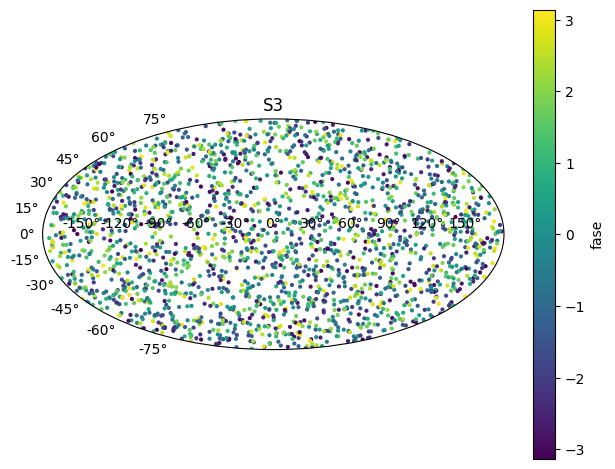

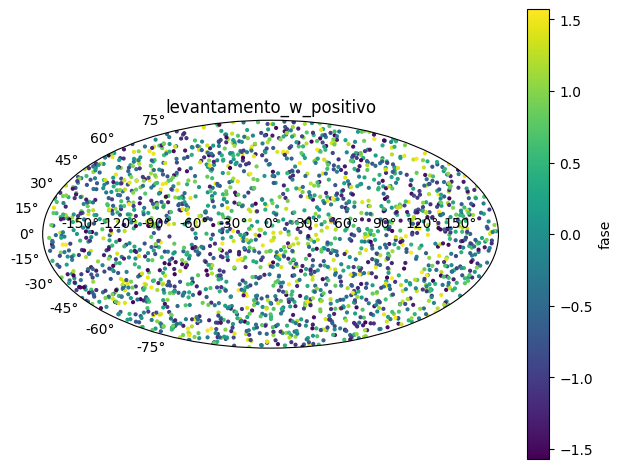

In [7]:
def qmul(q,p):
    w,v=q[0],q[1:];s,u=p[0],p[1:]
    return np.r_[w*s-v@u,w*u+s*v+np.cross(v,u)]
def qrot(q):
    w,x,y,z=q
    return np.array([[1-2*(y*y+z*z),2*(x*y-w*z),2*(x*z+w*y)],
                     [2*(x*y+w*z),1-2*(x*x+z*z),2*(y*z-w*x)],
                     [2*(x*z-w*y),2*(y*z+w*x),1-2*(x*x+y*y)]])
def hopf(Q):
    a,b,c,d=Q.T
    return np.column_stack((2*(a*c+b*d),2*(b*c-a*d),a*a+b*b-c*c-d*d))
def fibre(p,n=700):
    x,y,z=p;q=np.array([1+z,0,x,-y]);q/=np.linalg.norm(q)
    a,b,c,d=q;t=np.linspace(0,2*np.pi,n,endpoint=False)
    return np.column_stack((a*np.cos(t)-b*np.sin(t),a*np.sin(t)+b*np.cos(t),
                            c*np.cos(t)-d*np.sin(t),c*np.sin(t)+d*np.cos(t)))
q,p=sphere(2,4,rng)
err=np.max(abs(qrot(qmul(q,p))-qrot(q)@qrot(p)))
assert err<1e-12 and np.allclose(qrot(q),qrot(-q))
assert np.allclose(qrot([1,0,0,0]),np.eye(3)) and np.allclose(qrot([-1,0,0,0]),np.eye(3))
print('Erro do homomorfismo:',err)
p1=np.array([np.sqrt(.75),0,.5]);p2=np.array([np.sqrt(.75)*np.cos(.4),np.sqrt(.75)*np.sin(.4),.5])
F1=fibre(p1);F2=fibre(p2)
assert np.max(abs(hopf(F1)-p1))<1e-12
q0=F1[0]*np.array([1,1,1,-1]);t=.31
right=qmul(q0,np.array([np.cos(t),np.sin(t),0,0]))*np.array([1,1,1,-1])
assert np.allclose(hopf(right[None]),p1)
print('Distância mínima amostrada entre fibras:',distance.cdist(F1,F2).min())
def gauss_link(F,G):
    A=F[:,:3]/(1-F[:,3:4]);B=G[:,:3]/(1-G[:,3:4])
    da=np.roll(A,-1,axis=0)-A;db=np.roll(B,-1,axis=0)-B
    am=(A+np.roll(A,-1,axis=0))/2;bm=(B+np.roll(B,-1,axis=0))/2
    r=am[:,None]-bm[None]
    return np.sum(np.sum(np.cross(da[:,None],db[None])*r,axis=-1)/np.linalg.norm(r,axis=-1)**3)/(4*np.pi)
links=[{'pontos_por_fibra':n,'enlace':gauss_link(fibre(p1,n),fibre(p2,n))} for n in [150,300,600]]
link_df=table(links,'ex06_enlace',OUT)
assert abs(abs(link_df.enlace.iloc[-1])-1)<.02
Q=sphere(2200,4,rng);Qlift=Q*np.where(Q[:,0:1]<0,-1,1)
assert np.allclose(hopf(Q),hopf(Qlift))
for name,Z in [('S3',Q),('levantamento_w_positivo',Qlift)]:
    H=hopf(Z);lon=np.arctan2(H[:,1],H[:,0]);lat=np.arcsin(np.clip(H[:,2],-1,1))
    fig=plt.figure();ax=fig.add_subplot(111,projection='mollweide')
    sc=ax.scatter(lon,lat,c=np.arctan2(Z[:,1],Z[:,0]),s=4);fig.colorbar(sc,ax=ax,label='fase')
    ax.set_title(name);figure('ex06_'+name,OUT)

## Exercício 7

> **Exercise 7 — quantifying the curse.**
> (a) Verify the sub-Gaussian bound directly: for each $n$, estimate
> $\mathbb{P}(|x_1| > t)$ by simulation and plot $-\log \mathbb{P}$ against $n t^2$.
> Do the curves collapse onto a line? What constant $c$ do you measure?
>
> (b) *Sample complexity.* To cover $S^{n-1}$ so that every point is within
> geodesic distance $\varepsilon$ of a sample, roughly how many i.i.d. points are
> needed? Measure the covering radius of an $N$-point sample as a function of $N$
> for $n = 3, 5, 10$ and compare with the theoretical $N \sim \varepsilon^{-(n-1)}$.
>
> (c) *The escape.* Repeat (b) for points sampled from a fixed $2$-dimensional
> great subsphere $S^2 \subset S^{n-1}$. The covering radius should now be governed
> by the *intrinsic* dimension $2$, not by $n$. This single experiment is the
> content of the manifold hypothesis — and the subject of the next section.

### Resolução

**(a)** A densidade da coordenada implica caudas de escala $\exp(-c n t^2)$, mas não igualdade com uma exponencial única. No regime aproximadamente gaussiano e de caudas moderadas, o coeficiente dominante é próximo de $1/2$; prefatores, dimensões pequenas e eventos muito raros impedem um colapso exato. Se não há eventos observados, não se deve substituir probabilidade zero por um logaritmo finito e tratá-lo como medida.

**(b)** Uma rede determinística de resolução $\varepsilon$ exige ordem $\varepsilon^{-(n-1)}$ pontos. Para cobertura **uniforme com amostras i.i.d.**, há tipicamente um fator logarítmico: $R_N\asymp(\log N/N)^{1/(n-1)}$, sob condições regulares. O máximo sobre sondas finitas é uma **cota inferior** do verdadeiro raio de cobertura. Não confundir distância média ao vizinho com cobertura do pior ponto.

**(c)** Para dados e sondas na mesma grande $S^2$, vale a dimensão intrínseca 2, independentemente de se armazenarem 3, 5 ou 10 coordenadas. Sondas fora da subvariedade fariam outra pergunta, que as amostras nunca poderiam resolver.

n= 3 inclinação empírica de cauda= 1.617308061361944
n= 5 inclinação empírica de cauda= 0.9884470473132208
n= 10 inclinação empírica de cauda= 1.1113401986617608
n= 30 inclinação empírica de cauda= 0.6967390151549249


n= 100 inclinação empírica de cauda= 0.5780468283192919


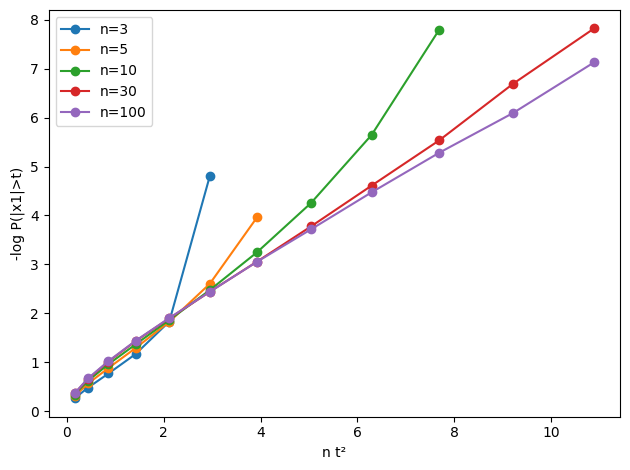

  n        t  eventos        p       nt2  menos_log_p
  3 0.230940    61475 0.768437  0.160000     0.263396
  3 0.383151    49400 0.617500  0.440413     0.482076
  3 0.535361    37054 0.463175  0.859835     0.769650
  3 0.687572    24926 0.311575  1.418264     1.166115
  3 0.839782    12802 0.160025  2.115702     1.832425
  3 0.991993      656 0.008200  2.952149     4.803621
  5 0.178885    58891 0.736138  0.160000     0.306338
  5 0.296787    45469 0.568362  0.440413     0.564996
  5 0.414689    33113 0.413913  0.859835     0.882101
  5 0.532591    22061 0.275763  1.418264     1.288215
  5 0.650493    12882 0.161025  2.115702     1.826196
  5 0.768394     5921 0.074012  2.952149     2.603521
  5 0.886296     1523 0.019037  3.927603     3.961345
 10 0.126491    57016 0.712700  0.160000     0.338695
 10 0.209860    42941 0.536763  0.440413     0.622200
 ..      ...      ...      ...       ...          ...
 30 0.506228      316 0.003950  7.688017     5.534040
 30 0.554362       99 0.0012

 n_ambiente  dim_intrinseca    N  raio_sondas
          3               2  100     0.441536
          3               2  300     0.308538
          3               2 1000     0.189391
          3               2 3000     0.114311
          3               2  100     0.447311
          3               2  300     0.284058
          3               2 1000     0.155109
          3               2 3000     0.129923
          5               4  100     0.874721
          5               4  300     0.661943
          5               4 1000     0.465675
          5               4 3000     0.379445
          5               2  100     0.525511
          5               2  300     0.424131
          5               2 1000     0.180529
          5               2 3000     0.100957
         10               9  100     1.104745
         10               9  300     0.941597
         10               9 1000     0.802990
         10               9 3000     0.702697
         10               2  100  

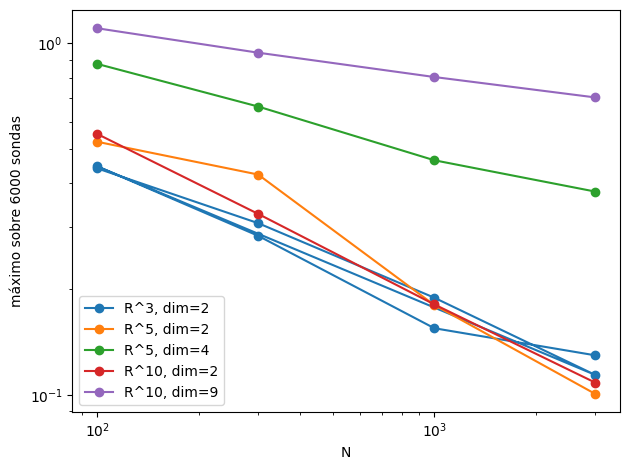

In [8]:
rows=[];plt.figure()
for n in [3,5,10,30,100]:
    X=sphere(80000,n,rng);ts=np.linspace(.4,3.3,12)/np.sqrt(n);xs=[];ys=[]
    for t in ts[ts<1]:
        count=int((abs(X[:,0])>t).sum());p=count/len(X)
        if count>=20:
            xs.append(n*t*t);ys.append(-np.log(p));rows.append(dict(n=n,t=t,eventos=count,p=p,nt2=n*t*t,menos_log_p=-np.log(p)))
    plt.plot(xs,ys,'o-',label=f'n={n}')
    if len(xs)>3:print('n=',n,'inclinação empírica de cauda=',np.polyfit(xs[-5:],ys[-5:],1)[0])
plt.xlabel('n t²');plt.ylabel('-log P(|x1|>t)');plt.legend();figure('ex07_caudas',OUT)
table(rows,'ex07_caudas',OUT)
rows=[]
for n in [3,5,10]:
    for intrinsic in [n-1,2]:
        for N in [100,300,1000,3000]:
            X=sphere(N,intrinsic+1,rng);Q=sphere(6000,intrinsic+1,rng)
            if intrinsic+1<n:
                A=np.linalg.qr(rng.normal(size=(n,intrinsic+1)))[0];X=X@A.T;Q=Q@A.T
            d=cKDTree(X).query(Q,k=1)[0];radius=np.max(2*np.arcsin(np.clip(d/2,0,1)))
            rows.append(dict(n_ambiente=n,dim_intrinseca=intrinsic,N=N,raio_sondas=radius))
cover_df=table(rows,'ex07_cobertura',OUT)
plt.figure()
for (n,d),g in cover_df.groupby(['n_ambiente','dim_intrinseca']):plt.loglog(g.N,g.raio_sondas,'o-',label=f'R^{n}, dim={d}')
plt.xlabel('N');plt.ylabel('máximo sobre 6000 sondas');plt.legend();figure('ex07_cobertura',OUT)

## Exercício 8

> **Exercise 8 — when does the recovery break?**
> (a) Sweep the noise level $\sigma$ from $10^{-4}$ to $1$ and plot the estimated
> intrinsic dimension (say, the number of local singular values above $10\%$ of the
> largest) against $\sigma$. At what noise level does the tangent plane drown?
> Relate the answer to the neighbourhood radius.
>
> (b) Replace the *linear* isometry $A$ by a nonlinear embedding — e.g. append the
> coordinates $(x^2, y^2, z^2, xy, \dots)$ — and repeat. PCA should now fail while
> local PCA still succeeds. Explain the difference in one sentence.
>
> (c) Do the same for $S^3 \subset \mathbb{R}^4$ embedded in $\mathbb{R}^{100}$: does
> local PCA return $3$? How does the required number of neighbours $k$ scale with
> the intrinsic dimension, and how does this reproduce the curse of §6?

### Resolução

**(a)** O espectro local tem contribuições tangenciais de ordem $r$, de curvatura de ordem $r^2$ e de ruído. O limiar de 10% não é intrinsecamente geométrico: pode contar curvatura ou eliminar direções tangenciais. Em dimensão ambiente 100, o deslocamento total do ruído i.i.d. é de escala $\sigma\sqrt{100}$; o parâmetro por coordenada sozinho não mede o tamanho da perturbação. Relato também o raio observado e não prometo dimensão 2 para todo $k$.

**(b)** A PCA global mede um subespaço afim; a PCA local aproxima o plano tangente, desde que a vizinhança seja pequena, bem amostrada e pouco ruidosa. Uma imersão não linear pode aumentar a dimensão do span sem alterar a dimensão intrínseca.

**(c)** A esfera $S^3$ possui espaço tangente de dimensão 3. Para $k$ vizinhos em dimensão intrínseca $d$, o raio é de ordem $(k/N)^{1/d}$. É necessário $k>d$ e estabilidade estatística; manter o mesmo raio requer $N$ crescendo como $r^{-d}$. Não há uma lei universal apenas para $k(d)$ sem fixar $N$, raio, ruído e precisão.

   sigma  dimensao_estimada  raio_mediano  ruido_norma_tipica
0.000100               2.00      0.116959            0.001000
0.000316               2.00      0.116872            0.003162
0.001000               2.00      0.117451            0.010000
0.003162              10.75      0.126601            0.031623
0.010000              29.00      0.181271            0.100000
0.031623              29.00      0.452279            0.316228
0.100000              29.00      1.300187            1.000000
0.316228              29.00      3.807415            3.162278
1.000000              29.00     11.812192           10.000000


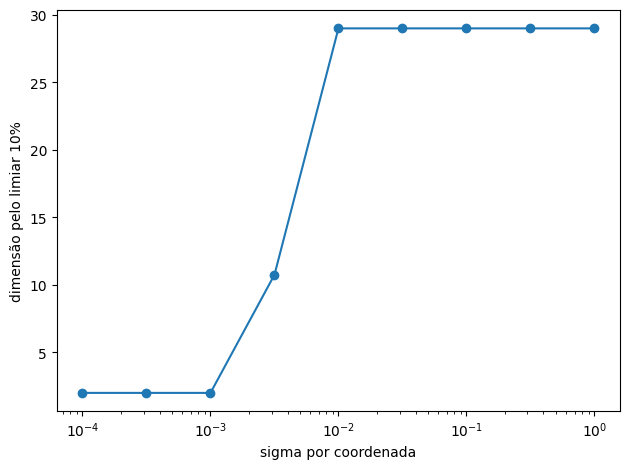

Embedding não linear: posto global= 8 dimensão local= 2.0


    N  k  dim_local     raio    s4_s1
 4000 12      3.000 0.233021 0.049983
 4000 24      3.000 0.296597 0.071832
 4000 48      3.375 0.376674 0.097701
12000 12      3.000 0.159690 0.031960
12000 24      3.000 0.206448 0.050540
12000 48      3.000 0.262523 0.068828
30000 12      3.000 0.122023 0.027638
30000 24      3.000 0.156640 0.038393
30000 48      3.000 0.198066 0.050775


,N,k,dim_local,raio,s4_s1
0,4000,12,3.000,0.233021,0.049983
1,4000,24,3.000,0.296597,0.071832
2,4000,48,3.375,0.376674,0.097701
3,12000,12,3.000,0.159690,0.031960
4,12000,24,3.000,0.206448,0.050540
5,12000,48,3.000,0.262523,0.068828
6,30000,12,3.000,0.122023,0.027638
7,30000,24,3.000,0.156640,0.038393
8,30000,48,3.000,0.198066,0.050775


In [9]:
def local_dim(X,k=25,nq=60,threshold=.1):
    ids=np.linspace(0,len(X)-1,nq,dtype=int);ds,ix=cKDTree(X).query(X[ids],k=k+1)
    dims=[];spec=[]
    for row in ix[:,1:]:
        Z=X[row]-X[row].mean(0);s=np.linalg.svd(Z,compute_uv=False)
        dims.append(np.sum(s>threshold*s[0]));spec.append(s[:6]/s[0])
    return np.mean(dims),np.median(ds[:,-1]),np.mean(spec,axis=0)
X=sphere(9000,3,rng);A=np.linalg.qr(rng.normal(size=(100,3)))[0];base=X@A.T
rows=[]
for sigma in np.logspace(-4,0,9):
    dim,radius,s=local_dim(base+sigma*rng.normal(size=base.shape),k=30)
    rows.append(dict(sigma=sigma,dimensao_estimada=dim,raio_mediano=radius,ruido_norma_tipica=10*sigma))
noise_df=table(rows,'ex08_ruido',OUT)
plt.figure();plt.semilogx(noise_df.sigma,noise_df.dimensao_estimada,'o-');plt.xlabel('sigma por coordenada');plt.ylabel('dimensão pelo limiar 10%');figure('ex08_ruido',OUT)
x,y,z=X.T;nonlinear=np.column_stack((X,X*X,x*y,x*z,y*z))
s=np.linalg.svd(nonlinear-nonlinear.mean(0),compute_uv=False)
print('Embedding não linear: posto global=',sum(s>1e-9*s[0]),'dimensão local=',local_dim(nonlinear,k=25)[0])
rows=[]
for N in [4000,12000,30000]:
    X3=sphere(N,4,rng);A3=np.linalg.qr(rng.normal(size=(100,4)))[0]
    # Sem ruído nesta comparação, para isolar raio/amostragem/curvatura.
    for k in [12,24,48]:
        d,r,s=local_dim(X3@A3.T,k=k,nq=40)
        rows.append(dict(N=N,k=k,dim_local=d,raio=r,s4_s1=s[3]))
table(rows,'ex08_s3',OUT)

## Exercício 9

> **Exercise 9 — the learning curve.**
> Fix the degree at the value validation selected, and sweep $N_{\text{train}}$ from
> $10$ to $5000$ on log axes. Plot test MSE against $N$, averaged over (say) 20
> random draws so that you see the *variance* as well as the mean. You should find
> the error falling like a power of $N$ until it saturates at the noise floor
> $\sigma^2$. Which of the three terms in the bias–variance decomposition does each
> regime correspond to?

### Resolução

Uso validação independente para escolher o grau e congelo essa escolha antes da curva de aprendizagem. Para cada tamanho de treino, faço 20 amostras independentes.

**Distinção necessária:** o notebook original testa contra $f^\star$ sem ruído. Nesse teste, o piso $\sigma^2$ **não** existe. Contra novos rótulos $Y=f^\star(X)+\epsilon$, existe:
$$E[(\hat f(X)-Y)^2]=\operatorname{Bias}^2+\operatorname{Var}(\hat f(X))+\sigma^2.$$

Produzo as duas curvas. Grau insuficiente deixa viés de aproximação; pouca amostra dá variância elevada (especialmente perto da interpolação); muito dado reduz variância e deixa viés mais ruído irredutível. Abaixo da quantidade de parâmetros efetivos, a escolha da solução de norma mínima também importa.

Grau escolhido pela validação: 3


   N  repeticao  MSE_sem_ruido  MSE_com_ruido
  10          0       0.378384       0.400446
  10          1       0.258055       0.280336
  10          2       0.392259       0.413739
  10          3       0.556686       0.578084
  10          4       0.385291       0.408333
  10          5       3.289493       3.322590
  10          6       0.184381       0.204871
  10          7       0.221580       0.245251
  10          8       0.245756       0.267455
  10          9       0.349336       0.373652
  10         10       0.506107       0.532526
  10         11       0.423898       0.446280
  10         12       0.134343       0.158235
  10         13       0.348988       0.372136
  10         14       0.222911       0.243977
 ...        ...            ...            ...
5000          5       0.000046       0.022489
5000          6       0.000032       0.022431
5000          7       0.000054       0.022502
5000          8       0.000061       0.022476
5000          9       0.000118    

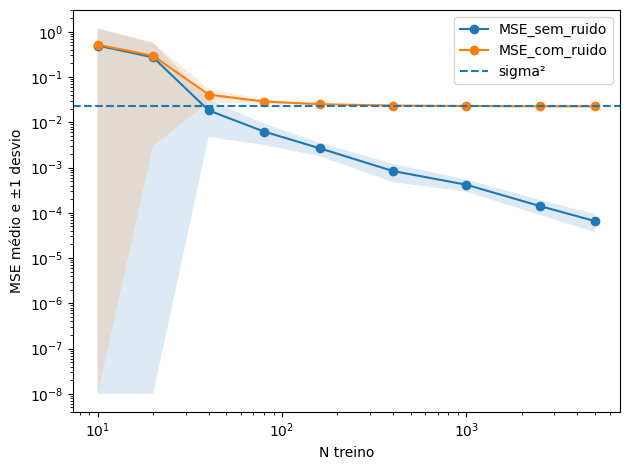

In [10]:
sigma=.15;Xsel=sphere(400,3,rng);Xval=sphere(1500,3,rng)
ysel=target(Xsel)+sigma*rng.normal(size=len(Xsel));yv=target(Xval)+sigma*rng.normal(size=len(Xval))
choices=[]
for D in range(1,7):
    F=real_harmonics(Xsel,D);w=np.linalg.lstsq(F,ysel,rcond=None)[0]
    choices.append(mean_squared_error(yv,real_harmonics(Xval,D)@w))
Dsel=int(np.argmin(choices))+1;print('Grau escolhido pela validação:',Dsel)
Xt=sphere(3000,3,rng);Ft=real_harmonics(Xt,Dsel);truth=target(Xt);yn=truth+sigma*rng.normal(size=len(Xt))
rows=[]
for N in [10,20,40,80,160,400,1000,2500,5000]:
    for rep in range(20):
        X=sphere(N,3,rng);y=target(X)+sigma*rng.normal(size=N)
        w=np.linalg.lstsq(real_harmonics(X,Dsel),y,rcond=None)[0];yp=Ft@w
        rows.append(dict(N=N,repeticao=rep,MSE_sem_ruido=mean_squared_error(truth,yp),MSE_com_ruido=mean_squared_error(yn,yp)))
learn_df=table(rows,'ex09_curva_aprendizagem',OUT)
agg=learn_df.groupby('N')[['MSE_sem_ruido','MSE_com_ruido']].agg(['mean','std'])
plt.figure()
for col in ['MSE_sem_ruido','MSE_com_ruido']:
    plt.loglog(agg.index,agg[col]['mean'],'o-',label=col)
    lo=np.maximum(agg[col]['mean']-agg[col]['std'],1e-8);hi=agg[col]['mean']+agg[col]['std']
    plt.fill_between(agg.index,lo,hi,alpha=.15)
plt.axhline(sigma*sigma,linestyle='--',label='sigma²');plt.xlabel('N treino');plt.ylabel('MSE médio e ±1 desvio');plt.legend();figure('ex09_aprendizagem',OUT)

## Exercício 10

> **Exercise 10 — equivariance, cheaply.**
> The target $f^\star$ was built from harmonics, and the space $\mathcal{H}_\ell$ is an
> irreducible representation of $SO(3)$. Exploit this: instead of raw monomials, fit
> in a basis of *harmonic* polynomials of degree exactly $\ell$ for $\ell \leq D$
> (obtain it by orthonormalising the monomial features against a large uniform
> sample — a QR factorisation). Compare the conditioning of the two design matrices
> and the test error at fixed $N_{\text{train}}$.
>
> This is the whole idea of Lecture 10 in miniature: **the same hypothesis space in a
> symmetry-adapted basis is a better hypothesis space in practice.**

### Resolução

As restrições dos monômios de grau $\leq D$ a $S^2$ têm dimensão $(D+1)^2$, menor que $\binom{D+3}{3}$. A matriz bruta contém dependências exatas, logo seu número de condição usual é infinito; reporto também o número de condição restrito aos valores singulares numericamente não nulos.

Uma QR **genérica** só ortonormaliza; ela não fornece automaticamente polinômios harmônicos homogêneos de grau definido. Para isso, pode-se remover os graus inferiores em ordem e controlar dependências, ou usar os harmônicos esféricos conhecidos. Faço ambas as ideias: SVD/QR empírica para branquear o mesmo espaço e uma base harmônica real para separar os blocos $\mathcal H_\ell$.

Com posto completo no espaço efetivo e sem regularização, as previsões de mínimos quadrados no mesmo espaço coincidem em aritmética exata. Melhor condicionamento não cria uma classe de funções nova nem garante menor erro estatístico. Em regime subdeterminado, ou com penalização da norma dos coeficientes, trocar a base altera a escolha implícita da solução. Também não torna automaticamente um estimador escalar invariante a rotações: o espaço de funções é estável pela ação, o alvo pode não ser.

In [11]:
D=6;Xq=fibonacci(5000);Fq=poly(Xq,D)
U,s,Vt=np.linalg.svd(Fq/np.sqrt(len(Xq)),full_matrices=False);keep=s>1e-11*s[0]
T=Vt[keep].T/s[keep]
# A SVD remove o núcleo; a QR fornece a mesma ortonormalização no espaço efetivo.
Q,R=np.linalg.qr(Fq@T,mode='reduced');Tqr=T@np.linalg.inv(R)*np.sqrt(len(Xq))
assert np.max(abs((Fq@Tqr).T@(Fq@Tqr)/len(Xq)-np.eye(keep.sum())))<1e-9
X=sphere(200,3,rng);Xt=sphere(3000,3,rng);y=target(X)+.15*rng.normal(size=len(X))
rows=[];preds={}
for name,F,Ftest in [('monômios',poly(X,D),poly(Xt,D)),('QR do espaço efetivo',poly(X,D)@Tqr,poly(Xt,D)@Tqr),
                      ('harmônicos reais',real_harmonics(X,D),real_harmonics(Xt,D))]:
    sv=np.linalg.svd(F,compute_uv=False);sv=sv[sv>1e-11*sv[0]]
    w=np.linalg.lstsq(F,y,rcond=None)[0];preds[name]=Ftest@w
    rows.append(dict(base=name,colunas=F.shape[1],posto=len(sv),condicao_na_imagem=sv[0]/sv[-1],MSE=mean_squared_error(target(Xt),preds[name])))
table(rows,'ex10_bases',OUT)
print('Diferença máxima de previsões:',np.max(abs(preds['monômios']-preds['harmônicos reais'])))
assert np.max(abs(preds['monômios']-preds['harmônicos reais']))<1e-7

                base  colunas  posto  condicao_na_imagem      MSE
            monômios       84     49          164.259900 0.005695
QR do espaço efetivo       49     49            4.279223 0.005695
    harmônicos reais       49     49            4.279298 0.005695
Diferença máxima de previsões: 1.3461454173580023e-14


## Exercício 11

> **Exercise 11 — a real geometric label.** *(mini-project seed)*
> Replace $f^\star$ by something you have to *compute* rather than write down. For
> instance: sample an ellipsoid $\{x^2/a^2 + y^2/b^2 + z^2/c^2 = 1\}$, and let the
> label at each point be the Gaussian curvature there (closed form available, so you
> can check). Train a model to predict curvature from the local point-cloud
> geometry alone — say, from the sorted distances to the $k$ nearest neighbours,
> which is a rotation- and translation-invariant feature.
>
> Does it transfer to a surface it was never trained on? This question — *does a
> geometric quantity learned on one family of shapes generalise to another* — is a
> perfectly good starting point for the mini-project.

### Resolução

Para $F(x)=x^2/a^2+y^2/b^2+z^2/c^2-1$, a curvatura gaussiana é
$$K(x)=\frac{1}{a^2b^2c^2\left(x^2/a^4+y^2/b^4+z^2/c^4\right)^2}.$$
Por exemplo, na esfera de raio $r$ ela dá $1/r^2$. A expressão segue de $K=(\nabla F)^T\operatorname{cof}(\nabla^2F)\nabla F/\|\nabla F\|^4$.

Treino um regressor nas distâncias ordenadas aos 20 vizinhos de pontos de **vários elipsoides**, separando treino, validação e teste por superfície. Testo ainda uma esfera e um toro não vistos. Os alvos do toro $((R+r\cos v)\cos u,(R+r\cos v)\sin u,r\sin v)$ são $K=\cos v/[r(R+r\cos v)]$ e podem ser negativos, ao contrário dos elipsoides.

Amostro elipsoides uniformemente em área por rejeição: o fator jacobiano do mapa $u\mapsto\operatorname{diag}(a,b,c)u$ é $abc\|\operatorname{diag}(a^{-1},b^{-1},c^{-1})u\|$. Assim evito que o modelo apenas aprenda um viés de amostragem por latitude. Mesmo assim, distâncias locais dependem de densidade, escala e ruído; não identificam automaticamente curvatura com sinal. A resposta à transferência deve vir do erro medido, não da invariância das características.

       superficie      MSE      MAE  baseline_MSE
elipsoide inédito 0.128925 0.272927      0.134641
   esfera inédita 0.018987 0.102623      0.007451
     toro inédito 1.020821 0.698417      1.195743


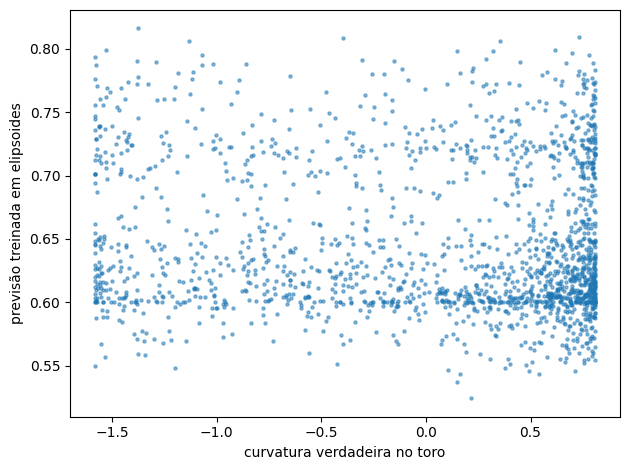

In [12]:
from sklearn.ensemble import RandomForestRegressor

def ellipsoid_data(axes,n,rng):
    axes=np.asarray(axes,float);parts=[];total=0
    while total<n:
        u=sphere(2*n,3,rng);prob=np.linalg.norm(u/axes,axis=1)/np.max(1/axes)
        accepted=u[rng.random(len(u))<prob]*axes;parts.append(accepted);total+=len(accepted)
    X=np.concatenate(parts)[:n]
    K=1/(np.prod(axes)**2*np.sum(X*X/axes**4,axis=1)**2)
    return X,K

def local_features(X,k=20):return cKDTree(X).query(X,k=k+1)[0][:,1:]
Ftr=[];ytr=[]
train_axes=[(.8,1.,1.2),(1.,1.2,1.5),(.7,.9,1.3),(1.1,1.3,1.6),(.9,1.3,1.7)]
for axes in train_axes:
    X,K=ellipsoid_data(axes,1800,rng);Ftr.append(local_features(X));ytr.append(K)
Ftr=np.vstack(Ftr);ytr=np.concatenate(ytr)
Xv,Kv=ellipsoid_data((.85,1.15,1.4),1800,rng);Fv=local_features(Xv)
candidates=[]
for leaf in [3,15,40]:
    model=RandomForestRegressor(n_estimators=100,min_samples_leaf=leaf,random_state=0,n_jobs=1).fit(Ftr,ytr)
    candidates.append((mean_squared_error(Kv,model.predict(Fv)),model))
model=min(candidates,key=lambda z:z[0])[1]
rows=[]
for name,axes in [('elipsoide inédito',(.95,1.1,1.45)),('esfera inédita',(1.2,1.2,1.2))]:
    X,K=ellipsoid_data(axes,1800,rng);yp=model.predict(local_features(X))
    rows.append(dict(superficie=name,MSE=mean_squared_error(K,yp),MAE=np.mean(abs(K-yp)),baseline_MSE=mean_squared_error(K,np.full(len(K),ytr.mean()))))
R,r=1.7,.55;us=[];vs=[];total=0
while total<1800:
    u=rng.uniform(0,2*np.pi,4000);v=rng.uniform(0,2*np.pi,4000);ok=rng.random(4000)<(R+r*np.cos(v))/(R+r)
    us.append(u[ok]);vs.append(v[ok]);total+=ok.sum()
u=np.concatenate(us)[:1800];v=np.concatenate(vs)[:1800]
X=np.column_stack(((R+r*np.cos(v))*np.cos(u),(R+r*np.cos(v))*np.sin(u),r*np.sin(v)))
K=np.cos(v)/(r*(R+r*np.cos(v)));yp=model.predict(local_features(X))
rows.append(dict(superficie='toro inédito',MSE=mean_squared_error(K,yp),MAE=np.mean(abs(K-yp)),baseline_MSE=mean_squared_error(K,np.full(len(K),ytr.mean()))))
curv_df=table(rows,'ex11_transferencia',OUT)
plt.figure();plt.scatter(K,yp,s=5,alpha=.5);plt.xlabel('curvatura verdadeira no toro');plt.ylabel('previsão treinada em elipsoides');figure('ex11_toro',OUT)

## Exercício 12

> **Exercise 12 — double descent.** *(challenge)*
> Push the degree sweep in §8.4 to $D = 25$ (that is $3276$ monomials against $80$
> training points), keeping `np.linalg.lstsq`'s minimum-norm solution. Plot test MSE
> against $p/N$ on log axes. Do you see the error come back down past the
> interpolation threshold? Then repeat with $N_{\text{train}} = 400$ and check that
> the peak moves with $N$, not with $D$. Compare with Lecture 4.

### Resolução

Faço o sweep inteiro $D=1,\ldots,25$, inclusive os 3276 monômios em $D=25$, com `np.linalg.lstsq(..., rcond=None)`, para $N=80$ e $400$. A abscissa principal é $p_{\mathrm{efetivo}}/N=(D+1)^2/N$, não a quantidade redundante de monômios. O limiar algébrico é $D\approx\sqrt N-1$: cerca de 8 para 80 amostras e 19 para 400.

A interpolação e o pico observado podem diferir desse valor por condicionamento, corte numérico da SVD, realização de ruído e norma implícita dos monômios. O erro não é obrigado a diminuir monotonicamente após o pico. Reporto posto numérico e erro de treino para distinguir uma solução verdadeiramente interpoladora de truncamento numérico; não converto uma experiência em prova universal de double descent.

  N  D  p_monomios  p_efetivo  posto_numerico  razao_p_N   MSE_treino     MSE_teste
 80  1           4          4               4     0.0500 5.840480e-01      0.632305
 80  2          10          9               9     0.1125 2.052724e-01      0.215211
 80  3          20         16              16     0.2000 2.099630e-02      0.003486
 80  4          35         25              25     0.3125 1.741372e-02      0.009180
 80  5          56         36              36     0.4500 1.431473e-02      0.015706
 80  6          84         49              49     0.6125 9.336792e-03      0.042553
 80  7         120         64              64     0.8000 5.398327e-03      1.400071
 80  8         165         81              80     1.0125 1.625123e-24  49567.495427
 80  9         220        100              80     1.2500 6.402367e-28    159.257106
 80 10         286        121              80     1.5125 2.215346e-28     61.106284
 80 11         364        144              80     1.8000 6.138680e-28     78

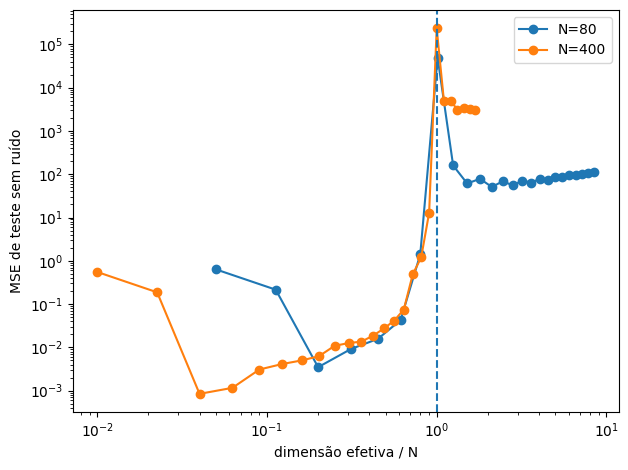

In [13]:
Xt=sphere(1800,3,rng);Fte,degs=poly(Xt,25,return_degrees=True);truth=target(Xt);rows=[]
for N in [80,400]:
    X=sphere(N,3,rng);F=poly(X,25);y=target(X)+.15*rng.normal(size=N)
    for D in range(1,26):
        mask=degs<=D;w,res,rank,sv=np.linalg.lstsq(F[:,mask],y,rcond=None)
        rows.append(dict(N=N,D=D,p_monomios=int(mask.sum()),p_efetivo=(D+1)**2,posto_numerico=rank,
                         razao_p_N=(D+1)**2/N,MSE_treino=mean_squared_error(y,F[:,mask]@w),MSE_teste=mean_squared_error(truth,Fte[:,mask]@w)))
double_df=table(rows,'ex12_double_descent',OUT)
plt.figure()
for N,g in double_df.groupby('N'):
    plt.loglog(g.razao_p_N,g.MSE_teste,'o-',label=f'N={N}')
    peak=g.loc[g.MSE_teste.idxmax()];print('Pico observado: N=',N,'D=',int(peak.D),'p/N=',peak.razao_p_N)
plt.axvline(1,linestyle='--');plt.xlabel('dimensão efetiva / N');plt.ylabel('MSE de teste sem ruído');plt.legend();figure('ex12_double_descent',OUT)
write_summary(OUT.parent/'README.md','estudar medida, distância, simetria e aprendizagem em esferas.',
'a representação e a partição dos dados mudam o problema estatístico.',
'foram resolvidos os 12 exercícios, com testes geométricos, curvas de aprendizagem e transferência de curvatura.',
f"a triangulação deu χ={chi}; o enlace numérico foi {link_df.enlace.iloc[-1]:.4f}; a validação escolheu grau {Dsel}.",
'vazamento não garante sucesso de um modelo linear; erro contra alvo sem ruído não tem piso sigma²; transferência entre superfícies exige avaliação própria.')